# Notebook 04: Research , Limitations and V3 Roadmap

This notebook summarizes the V2 pairs trading research pipeline using saved outputs from Notebook 03. No model fitting, pair selection, or backtest execution is performed here.

Current V2 results are presented as gross / zero-cost baseline results. Expanded transaction-cost and slippage scenarios are planned for V3.

## 1. Setup and Load Saved Outputs

This section imports the required Python libraries and loads the saved output files generated by Notebook 03. Notebook 04 is designed as a research summary and visual reporting notebook; it does not rerun pair selection, model fitting, portfolio construction, or backtesting.

The analysis in this notebook is based on the following saved output files:

 - `outputs/tables/v2_oos_pair_backtest_summary.csv`
 - `outputs/tables/v2_oos_pair_return_coverage.csv`
 - `outputs/tables/v2_oos_portfolio_construction_summary.csv`
 - `outputs/tables/v2_oos_portfolio_metrics.csv`
 - `outputs/tables/v2_test_oos_drawdown_pivot.csv`
 - `outputs/tables/v2_test_oos_method_summary.csv`
 - `outputs/tables/v2_test_oos_return_pivot.csv`
 - `outputs/tables/v2_test_oos_sharpe_pivot.csv`
 - `outputs/tables/v2_test_oos_tstat_pivot.csv`
 - `outputs/tables/v2_test_pair_backtest_summary.csv`
 - `outputs/tables/v2_test_pair_return_coverage.csv`
 - `outputs/tables/v2_test_portfolio_construction_summary.csv`
 - `outputs/tables/v2_test_oos_metrics_comparison.csv`
 - `outputs/tables/v2_test_portfolio_metrics.csv`

 Current V2 results are reported as gross / zero-cost baseline results. Expanded transaction-cost and slippage scenario analysis is planned for a future research iteration.

In [1]:
from pathlib import Path
import re
import pickle
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt

#Resolve project paths
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    
from src.research_plots import (
    plot_metric_by_fold,
    plot_cumulative_returns_by_fold,
    plot_drawdowns_by_fold
)

table_dir = project_root/"outputs/tables"

required_files = {
    "oos_pair_backtest_summary":"v2_oos_pair_backtest_summary.csv",
    "oos_pair_return_coverage":"v2_oos_pair_return_coverage.csv",
    "oos_portfolio_construction_summary":"v2_oos_portfolio_construction_summary.csv",
    "oos_portfolio_metrics":"v2_oos_portfolio_metrics.csv",
    "test_oos_drawdown_pivot":"v2_test_oos_drawdown_pivot.csv",
    "test_oos_method_summary":"v2_test_oos_method_summary.csv",
    "test_oos_metrics_comparison":"v2_test_oos_metrics_comparison.csv",
    "test_oos_return_pivot":"v2_test_oos_return_pivot.csv",
    "test_oos_sharpe_pivot":"v2_test_oos_sharpe_pivot.csv",
    "test_oos_tstat_pivot":"v2_test_oos_tstat_pivot.csv",
    "test_pair_backtest_summary":"v2_test_pair_backtest_summary.csv",
    "test_pair_return_coverage":"v2_test_pair_return_coverage.csv",
    "test_portfolio_construction_summary":"v2_test_portfolio_construction_summary.csv",
    "test_portfolio_metrics":"v2_test_portfolio_metrics.csv"
}

missing_files = [
    filename
    for filename in required_files.values()
    if not (table_dir/filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required Notebook 03 output files: \n"
        +"\n".join(missing_files)
    )
    
outputs = {
    name:pd.read_csv(table_dir/filename) for name, filename in required_files.items()
}

print(f"Loaded {len(outputs)} saved output tables from: {table_dir}")

Loaded 14 saved output tables from: c:\Users\Aditi\Aditi_Workspaces\VSCode\QuantProjects\pairs-trading-ai-tech\outputs\tables


In [2]:
#Assigning names to all the DataFrames
oos_pair_backtest_summary_df = outputs["oos_pair_backtest_summary"]
oos_pair_return_coverage_df = outputs["oos_pair_return_coverage"]
oos_portfolio_construction_summary_df = outputs["oos_portfolio_construction_summary"]
oos_portfolio_metrics_df = outputs["oos_portfolio_metrics"]
test_oos_drawdown_pivot_df = outputs["test_oos_drawdown_pivot"]
test_oos_method_summary_df = outputs["test_oos_method_summary"]
test_oos_metrics_comparison_df = outputs["test_oos_metrics_comparison"]
test_oos_return_pivot_df = outputs["test_oos_return_pivot"]
test_oos_sharpe_pivot_df = outputs["test_oos_sharpe_pivot"]
test_oos_tstat_pivot_df = outputs["test_oos_tstat_pivot"]
test_pair_backtest_summary_df = outputs["test_pair_backtest_summary"]
test_pair_return_coverage_df = outputs["test_pair_return_coverage"]
test_portfolio_construction_summary_df = outputs["test_portfolio_construction_summary"]
test_portfolio_metrics_df = outputs["test_portfolio_metrics"]

In [3]:
#Quick regex check
available_tables = sorted(table_dir.glob("v2_*.csv"))

for path in available_tables:
    clean_name = re.sub(r"v2_|\.csv$","",path.name)
    print(clean_name)

oos_pair_backtest_summary
oos_pair_return_coverage
oos_portfolio_construction_summary
oos_portfolio_metrics
test_oos_drawdown_pivot
test_oos_method_summary
test_oos_metrics_comparison
test_oos_return_pivot
test_oos_sharpe_pivot
test_oos_tstat_pivot
test_pair_backtest_summary
test_pair_return_coverage
test_portfolio_construction_summary
test_portfolio_metrics


In [4]:
#Quick Validation check
for name, df in outputs.items():
    if df.empty:
        raise ValueError(f"{name} is empty.")
    else:
        print(f"{name} is a populated DataFrame of size: {df.shape}")

oos_pair_backtest_summary is a populated DataFrame of size: (3, 9)
oos_pair_return_coverage is a populated DataFrame of size: (3, 5)
oos_portfolio_construction_summary is a populated DataFrame of size: (3, 7)
oos_portfolio_metrics is a populated DataFrame of size: (9, 18)
test_oos_drawdown_pivot is a populated DataFrame of size: (9, 5)
test_oos_method_summary is a populated DataFrame of size: (6, 30)
test_oos_metrics_comparison is a populated DataFrame of size: (18, 11)
test_oos_return_pivot is a populated DataFrame of size: (9, 5)
test_oos_sharpe_pivot is a populated DataFrame of size: (9, 5)
test_oos_tstat_pivot is a populated DataFrame of size: (9, 5)
test_pair_backtest_summary is a populated DataFrame of size: (3, 9)
test_pair_return_coverage is a populated DataFrame of size: (3, 5)
test_portfolio_construction_summary is a populated DataFrame of size: (3, 7)
test_portfolio_metrics is a populated DataFrame of size: (9, 18)


## 2. Research Objective

This project evaluates whether equity pairs with historically stable long-term relationships can generate mean-reversion trading signals when their relative price behavior temporarily diverges from its usual pattern.

The V2 research framework uses a universe of 50 large-cap equities selected using late-2018 market-cap information. Seven years of daily price data are divided into three walk-forward folds. Each fold uses approximately three years of training data, one year of test data, and one year of held-out OOS validation data.

Within each fold, pair selection, hedge-ratio estimation, spread construction, z-score generation, and portfolio weighting are performed using fold-specific model artifacts. The selected pairs are then evaluated through pair-level backtests and aggregated into portfolio-level results using equal-weight, rank-weight, and inverse-half-life weighting methods.

The results presented in this notebook are gross / zero-cost baseline results. Transaction-cost and slippage scenario analysis is reserved for a future research iteration.

This notebook is intended as a research summary and diagnostic report. It is not investment advice, trading advice, or a recommendation to deploy capital.

## 3. Walk-Forward Design and Output Structure

This section summarizes the structure of the saved Notebook 03 outputs and the walk-forward validation design used in the V2 research pipeline.

The loaded outputs are stored in a Python dictionary, where each key is a short internal table name and each value is a populated pandas DataFrame loaded from a saved CSV file. This structure makes the research summary notebook reproducible because all downstream tables and plots are generated from saved Notebook 03 outputs rather than rerunning pair selection, model fitting, or backtesting.

The walk-forward design uses three folds. In each fold, model artifacts are estimated before the test and OOS windows are evaluated. Pair-level returns are then aggregated into portfolio-level results using multiple weighting methods.

In [5]:
print(type(outputs))
print(list(outputs.keys()))

<class 'dict'>
['oos_pair_backtest_summary', 'oos_pair_return_coverage', 'oos_portfolio_construction_summary', 'oos_portfolio_metrics', 'test_oos_drawdown_pivot', 'test_oos_method_summary', 'test_oos_metrics_comparison', 'test_oos_return_pivot', 'test_oos_sharpe_pivot', 'test_oos_tstat_pivot', 'test_pair_backtest_summary', 'test_pair_return_coverage', 'test_portfolio_construction_summary', 'test_portfolio_metrics']


### 3.1 Saved Output Object Structure

In [6]:
outputs_structure = []

for name, df in outputs.items():
    outputs_structure.append({
        "object_name":name,
        "object_type":type(df).__name__,
        "n_rows":df.shape[0],
        "n_cols":df.shape[1],
        "columns":list(df.columns)
    })

outputs_df = pd.DataFrame(outputs_structure)

outputs_df

,object_name,object_type,n_rows,n_cols,columns
0,oos_pair_backtest_summary,DataFrame,3,9,"[fold_id, n_pairs_expected, n_pairs_successful..."
1,oos_pair_return_coverage,DataFrame,3,5,"[fold_id, expected_pairs, returned_pairs, miss..."
2,oos_portfolio_construction_summary,DataFrame,3,7,"[fold_id, n_methods, n_failed_method_pairs, po..."
3,oos_portfolio_metrics,DataFrame,9,18,"[fold_id, weight_method, start_date, end_date,..."
4,test_oos_drawdown_pivot,DataFrame,9,5,"[fold_id, weight_method, oos, test, oos_minus_..."
5,test_oos_method_summary,DataFrame,6,30,"[dataset, weight_method, final_cumulative_retu..."
6,test_oos_metrics_comparison,DataFrame,18,11,"[fold_id, weight_method, final_cumulative_retu..."
7,test_oos_return_pivot,DataFrame,9,5,"[fold_id, weight_method, oos, test, oos_minus_..."
8,test_oos_sharpe_pivot,DataFrame,9,5,"[fold_id, weight_method, oos, test, oos_minus_..."
9,test_oos_tstat_pivot,DataFrame,9,5,"[fold_id, weight_method, oos, test, oos_minus_..."


The output inventory confirms that Notebook 04 loaded the saved Notebook 03 outputs into a dictionary of populated pandas DataFrames. Each row in the inventory represents one saved research artifact, including its object type, row count, column count, and available fields. This confirms that Notebook 04 is operating as a reporting layer rather than rerunning the research engine.

### 3.2 Walk-Forward Coverage Summary

In [7]:
print(test_pair_backtest_summary_df.columns)
print(oos_pair_backtest_summary_df.columns)
print(test_pair_return_coverage_df.columns)
print(oos_pair_return_coverage_df.columns)

Index(['fold_id', 'n_pairs_expected', 'n_pairs_successful', 'n_pairs_failed',
       'pair_returns_shape', 'total_missing_values', 'start_date', 'end_date',
       'status'],
      dtype='str')
Index(['fold_id', 'n_pairs_expected', 'n_pairs_successful', 'n_pairs_failed',
       'pair_returns_shape', 'total_missing_values', 'start_date', 'end_date',
       'status'],
      dtype='str')
Index(['fold_id', 'expected_pairs', 'returned_pairs', 'missing_pairs',
       'status'],
      dtype='str')
Index(['fold_id', 'expected_pairs', 'returned_pairs', 'missing_pairs',
       'status'],
      dtype='str')


In [8]:
test_summary = test_pair_backtest_summary_df[[
    'fold_id',
    'n_pairs_expected',
    'n_pairs_successful',
    'n_pairs_failed',
    'start_date',
    'end_date',
    'status'
]].rename(columns={
    'n_pairs_expected':'test_n_pairs_expected',
    'n_pairs_successful':'test_n_pairs_successful',
    'n_pairs_failed':'test_n_pairs_failed',
    'start_date':'test_start_date',
    'end_date':'test_end_date',
    'status':'test_status'
})

oos_summary = oos_pair_backtest_summary_df[[
    'fold_id',
    'n_pairs_expected',
    'n_pairs_successful',
    'n_pairs_failed',
    'start_date',
    'end_date',
    'status'
]].rename(columns={
    'n_pairs_expected':'oos_n_pairs_expected',
    'n_pairs_successful':'oos_n_pairs_successful',
    'n_pairs_failed':'oos_n_pairs_failed',
    'start_date':'oos_start_date',
    'end_date':'oos_end_date',
    'status':'oos_status'
})

walk_forward_summary_df = test_summary.merge(
    oos_summary,
    on="fold_id",
    how="outer"
)

walk_forward_summary_df

,fold_id,test_n_pairs_expected,test_n_pairs_successful,test_n_pairs_failed,test_start_date,test_end_date,test_status,oos_n_pairs_expected,oos_n_pairs_successful,oos_n_pairs_failed,oos_start_date,oos_end_date,oos_status
0,fold_1,50,50,0,2022-01-04 00:00:00+00:00,2022-12-30 00:00:00+00:00,success,50,50,0,2023-01-04 00:00:00+00:00,2023-12-29 00:00:00+00:00,success
1,fold_2,50,50,0,2023-01-04 00:00:00+00:00,2023-12-29 00:00:00+00:00,success,50,50,0,2024-01-03 00:00:00+00:00,2024-12-31 00:00:00+00:00,success
2,fold_3,24,24,0,2024-01-03 00:00:00+00:00,2024-12-31 00:00:00+00:00,success,24,24,0,2025-01-03 00:00:00+00:00,2025-12-31 00:00:00+00:00,success


The walk-forward summary confirms that all three folds produced populated test and OOS outputs. Each fold stores separate test and OOS date ranges, pair counts, and backtest status fields. This confirms that Notebook 04 is using saved fold-level outputs from Notebook 03 rather than recomputing the research engine.

## 4. Portfolio Construction Summary

This section summarizes the portfolio construction outputs generated in Notebook 03. The goal is to confirm that portfolio weights were successfully constructed across folds and weighting methods for both the test and OOS periods.

The portfolio construction stage aggregates selected pair-level returns into fold-level portfolio returns using multiple weighting methods, including equal weighting, rank-based weighting, and inverse-half-life weighting. This section focuses on construction coverage and diagnostics, not performance evaluation.

In [9]:
print(test_portfolio_construction_summary_df.columns)
print(oos_portfolio_construction_summary_df.columns)

test_construction_df = test_portfolio_construction_summary_df.copy()
oos_construction_df = oos_portfolio_construction_summary_df.copy()
test_construction_df["period"] = "test"
oos_construction_df["period"] = "oos"

construction_df = pd.concat([test_construction_df,oos_construction_df],ignore_index=True)

construction_display_df = construction_df[[
    "period",
    "fold_id",
    "n_methods",
    "n_failed_method_pairs",
    "portfolio_returns_shape",
    "start_date",
    "end_date",
    "status"
]].sort_values(["fold_id", "period"])

construction_df

Index(['fold_id', 'n_methods', 'n_failed_method_pairs',
       'portfolio_returns_shape', 'start_date', 'end_date', 'status'],
      dtype='str')
Index(['fold_id', 'n_methods', 'n_failed_method_pairs',
       'portfolio_returns_shape', 'start_date', 'end_date', 'status'],
      dtype='str')


,fold_id,n_methods,n_failed_method_pairs,portfolio_returns_shape,start_date,end_date,status,period
0,fold_1,3,0,"(250, 3)",2022-01-04 00:00:00+00:00,2022-12-30 00:00:00+00:00,success,test
1,fold_2,3,0,"(249, 3)",2023-01-04 00:00:00+00:00,2023-12-29 00:00:00+00:00,success,test
2,fold_3,3,0,"(251, 3)",2024-01-03 00:00:00+00:00,2024-12-31 00:00:00+00:00,success,test
3,fold_1,3,0,"(249, 3)",2023-01-04 00:00:00+00:00,2023-12-29 00:00:00+00:00,success,oos
4,fold_2,3,0,"(251, 3)",2024-01-03 00:00:00+00:00,2024-12-31 00:00:00+00:00,success,oos
5,fold_3,3,0,"(249, 3)",2025-01-03 00:00:00+00:00,2025-12-31 00:00:00+00:00,success,oos


The portfolio construction summary confirms that fold-level portfolio outputs were generated for both test and OOS periods across the configured weighting methods. This establishes that the saved Notebook 03 outputs contain the required portfolio-level artifacts for the performance analysis in the following sections.

## 5. Test Performance Results

This section summarizes portfolio-level performance during the test windows. These results evaluate how each weighting method performed after pair selection and model estimation were completed using the corresponding training window.

The test-period results are still not final robustness evidence; they are an intermediate validation layer before the held-out OOS results.

### 5.1 Test Performance Metrics Table

In [10]:
print(test_portfolio_metrics_df.columns)
test_metrics_df = test_portfolio_metrics_df[[
    "fold_id",
    "weight_method",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "annualized_alpha",
    "hit_rate",
    "newey_west_tstat",
    "newey_west_pvalue"
]].copy()

test_metrics_df = test_metrics_df.sort_values(["fold_id","weight_method"])
numeric_cols = test_metrics_df.select_dtypes(include="number").columns
test_metrics_df[numeric_cols] = test_metrics_df[numeric_cols].round(4)

print(test_metrics_df.columns)
print(test_metrics_df.head())

Index(['fold_id', 'weight_method', 'start_date', 'end_date', 'n_observations',
       'final_cumulative_return', 'mean_daily_return', 'annualized_return',
       'annualized_volatility', 'sharpe_ratio', 'max_drawdown', 'hit_rate',
       'alpha', 'annualized_alpha', 'newey_west_standard_error',
       'newey_west_tstat', 'newey_west_pvalue', 'newey_west_lags'],
      dtype='str')
Index(['fold_id', 'weight_method', 'annualized_return',
       'annualized_volatility', 'sharpe_ratio', 'max_drawdown',
       'annualized_alpha', 'hit_rate', 'newey_west_tstat',
       'newey_west_pvalue'],
      dtype='str')
  fold_id      weight_method  annualized_return  annualized_volatility  \
0  fold_1       equal_weight            -0.1695                 0.0897   
2  fold_1  inverse_half_life            -0.1692                 0.0852   
1  fold_1        rank_weight            -0.1108                 0.0710   
3  fold_2       equal_weight             0.0537                 0.0885   
5  fold_2  inverse_h

### 5.2 Visual - 1 Test Sharpe Ratio By Fold and Method

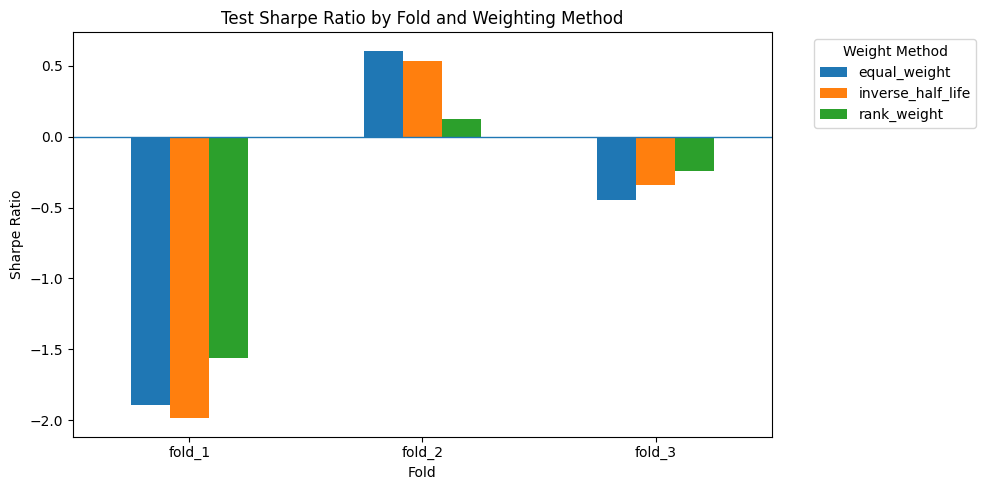

In [11]:
plot_metric_by_fold(
    metrics_df=test_metrics_df,
    metrics_col="sharpe_ratio",
    title="Test Sharpe Ratio by Fold and Weighting Method",
    ylabel="Sharpe Ratio"
)

### 5.3 Visual - 2 Test Annualized Return By Fold and Method

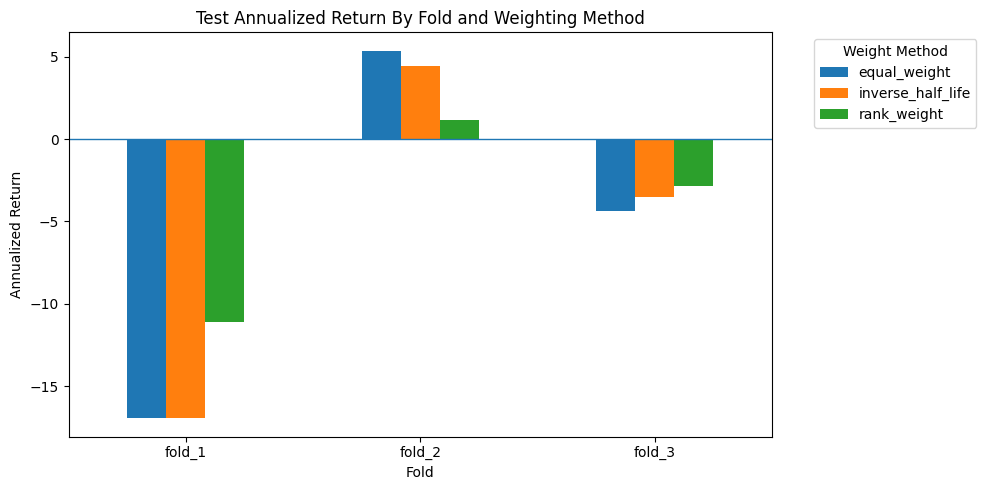

In [12]:
plot_metric_by_fold(
    metrics_df=test_metrics_df,
    metrics_col="annualized_return",
    title="Test Annualized Return By Fold and Weighting Method",
    ylabel="Annualized Return",
    scale=100
)

The test-period results vary across folds and weighting methods. This suggests that performance is not uniformly stable across market regimes. The next section evaluates whether any apparent test-period behavior persists into the held-out OOS windows.

## 6. OOS Performance Results

This section summarizes portfolio-level performance during the held-out OOS validation windows. The OOS periods are evaluated after pair selection, hedge-ratio estimation, spread construction, and portfolio weighting have already been defined using the corresponding training and test workflow from Notebook 03.

The purpose of this section is to evaluate whether the strategy behavior observed in the test periods persists in unseen market periods. These results are central to assessing robustness.

### 6.1 OOS Performance Metrics Table

In [13]:
print(oos_portfolio_metrics_df.columns)
oos_metrics_df = oos_portfolio_metrics_df[[
    "fold_id",
    "weight_method",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "annualized_alpha",
    "hit_rate",
    "newey_west_tstat",
    "newey_west_pvalue"
]].copy()

oos_metrics_df = oos_metrics_df.sort_values(["fold_id","weight_method"])
numeric_cols = oos_metrics_df.select_dtypes(include="number").columns
oos_metrics_df[numeric_cols] = oos_metrics_df[numeric_cols].round(4)

print(oos_metrics_df.columns)
print(oos_metrics_df.head())

Index(['fold_id', 'weight_method', 'start_date', 'end_date', 'n_observations',
       'final_cumulative_return', 'mean_daily_return', 'annualized_return',
       'annualized_volatility', 'sharpe_ratio', 'max_drawdown', 'hit_rate',
       'alpha', 'annualized_alpha', 'newey_west_standard_error',
       'newey_west_tstat', 'newey_west_pvalue', 'newey_west_lags'],
      dtype='str')
Index(['fold_id', 'weight_method', 'annualized_return',
       'annualized_volatility', 'sharpe_ratio', 'max_drawdown',
       'annualized_alpha', 'hit_rate', 'newey_west_tstat',
       'newey_west_pvalue'],
      dtype='str')
  fold_id      weight_method  annualized_return  annualized_volatility  \
0  fold_1       equal_weight             0.1262                 0.0868   
2  fold_1  inverse_half_life             0.1099                 0.0866   
1  fold_1        rank_weight             0.0878                 0.0769   
3  fold_2       equal_weight            -0.0958                 0.0603   
5  fold_2  inverse_h

### 6.2 Visual - 1 OOS Sharpe Ratio By Fold and Method

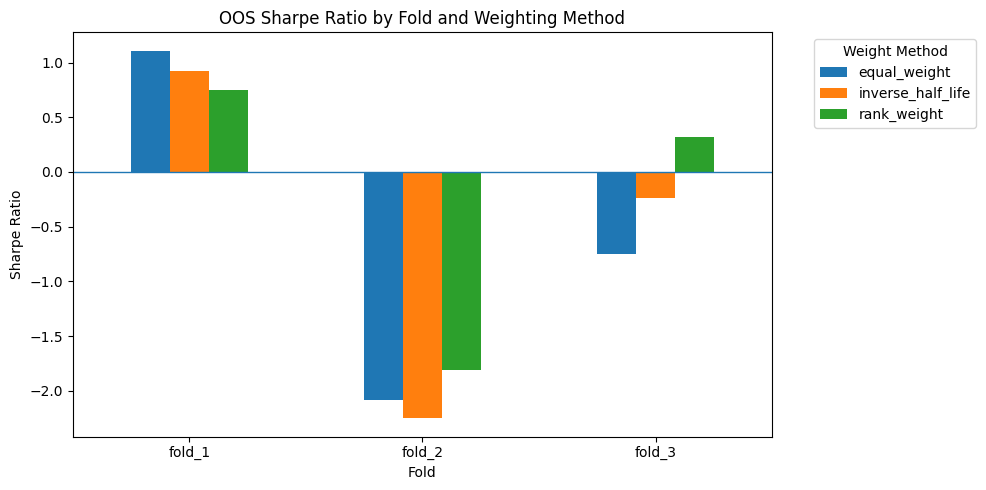

In [14]:
plot_metric_by_fold(
    metrics_df=oos_metrics_df,
    metrics_col="sharpe_ratio",
    title="OOS Sharpe Ratio by Fold and Weighting Method",
    ylabel="Sharpe Ratio"
)

### 6.3 Visual - 2 OOS Annualized Return By Fold and Method

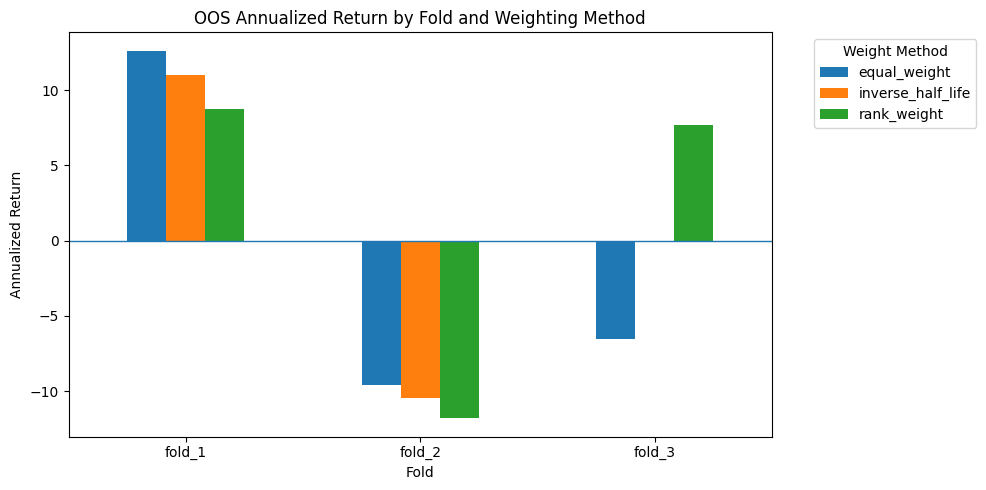

In [15]:
plot_metric_by_fold(
    metrics_df=oos_metrics_df,
    metrics_col="annualized_return",
    title="OOS Annualized Return by Fold and Weighting Method",
    ylabel="Annualized Return",
    scale=100
)

The OOS results are mixed across folds and weighting methods. No weighting method demonstrates consistently strong positive performance across all held-out OOS periods.

This suggests that the current V2 signal and portfolio construction framework is useful as a research infrastructure layer, but the current strategy configuration is not yet robust enough for capital deployment.

## 7. Test vs OOS Comparison

This section compares test-period and held-out OOS performance across folds and weighting methods. The goal is to evaluate whether performance observed during the test windows persists in unseen validation periods.

This comparison is central to the research conclusion. A strategy that performs well in test but weakens materially in OOS may be regime-sensitive, overfit, or insufficiently robust for deployment.

Question Answered: Did test-period performance survive into OOS?

### 7.1 Test vs OOS Metrics Comparison Table

Question Answered: What do the comparison files show across row level?

This subsection displays the saved test vs OOS comparison table generated in Notebook 03. The goal is to inspect how key performance metrics change between the test and held-out OOS periods across folds and weighting methods.

In [16]:
print(test_oos_metrics_comparison_df.columns)

required_cols = [
    "fold_id",
    "weight_method",
    "dataset",
    "annualized_return",
    "sharpe_ratio",
    "max_drawdown",
    "hit_rate",
    "newey_west_tstat",
    "newey_west_pvalue"
]
test_oos_metrics_df = (
    test_oos_metrics_comparison_df[required_cols]
    .sort_values(["fold_id","weight_method","dataset"])
    .round(4)
)

test_oos_metrics_df

Index(['fold_id', 'weight_method', 'final_cumulative_return',
       'annualized_return', 'annualized_volatility', 'sharpe_ratio',
       'max_drawdown', 'hit_rate', 'newey_west_tstat', 'newey_west_pvalue',
       'dataset'],
      dtype='str')


,fold_id,weight_method,dataset,annualized_return,sharpe_ratio,max_drawdown,hit_rate,newey_west_tstat,newey_west_pvalue
9,fold_1,equal_weight,oos,0.1262,1.1087,-0.0444,0.5221,1.5198,0.1286
0,fold_1,equal_weight,test,-0.1695,-1.8899,-0.1813,0.4360,-2.0385,0.0415
11,fold_1,inverse_half_life,oos,0.1099,0.9222,-0.0494,0.5141,1.3682,0.1712
2,fold_1,inverse_half_life,test,-0.1692,-1.9863,-0.1793,0.4360,-2.1064,0.0352
10,fold_1,rank_weight,oos,0.0878,0.7517,-0.0758,0.5100,1.2274,0.2197
1,fold_1,rank_weight,test,-0.1108,-1.5599,-0.1447,0.4560,-1.4795,0.1390
12,fold_2,equal_weight,oos,-0.0958,-2.0873,-0.1131,0.4382,-1.5921,0.1114
3,fold_2,equal_weight,test,0.0537,0.6076,-0.0547,0.4980,0.7223,0.4701
14,fold_2,inverse_half_life,oos,-0.1047,-2.2514,-0.1179,0.4183,-1.7205,0.0853
5,fold_2,inverse_half_life,test,0.0443,0.5375,-0.0589,0.4980,0.6350,0.5254


The comparison table shows that test and OOS behavior differs materially across folds. Fold 1 is negative during the test period but positive during OOS, while Fold 2 shows the opposite pattern, with positive test performance followed by negative OOS performance. Fold 3 remains weak or mixed across methods.

This indicates that the strategy behavior is not stable across validation periods. The following subsections summarize these differences by weighting method and visualize the key metrics.

## 7.2 Method Level Summary

Question Answered: Across folds, does any weighting method look consistently better?

In [17]:
print(test_oos_method_summary_df.columns)

required_cols = [
    "dataset",
    "weight_method",
    "annualized_return_mean",
    "annualized_return_median",
    "sharpe_ratio_mean",
    "sharpe_ratio_median",
    "max_drawdown_mean",
    "hit_rate_mean",
    "newey_west_tstat_mean"
]
test_oos_method_df = test_oos_method_summary_df[required_cols].copy()
numeric_cols = test_oos_method_df.select_dtypes(include="number").columns
test_oos_method_df[numeric_cols] = test_oos_method_df[numeric_cols].round(4)

print(test_oos_method_df)

Index(['dataset', 'weight_method', 'final_cumulative_return_mean',
       'final_cumulative_return_median', 'final_cumulative_return_min',
       'final_cumulative_return_max', 'annualized_return_mean',
       'annualized_return_median', 'annualized_return_min',
       'annualized_return_max', 'annualized_volatility_mean',
       'annualized_volatility_median', 'annualized_volatility_min',
       'annualized_volatility_max', 'sharpe_ratio_mean', 'sharpe_ratio_median',
       'sharpe_ratio_min', 'sharpe_ratio_max', 'max_drawdown_mean',
       'max_drawdown_median', 'max_drawdown_min', 'max_drawdown_max',
       'hit_rate_mean', 'hit_rate_median', 'hit_rate_min', 'hit_rate_max',
       'newey_west_tstat_mean', 'newey_west_tstat_median',
       'newey_west_tstat_min', 'newey_west_tstat_max'],
      dtype='str')
  dataset      weight_method  annualized_return_mean  \
0     oos       equal_weight                 -0.0116   
1     oos  inverse_half_life                  0.0014   
2     oos   

The method-level summary aggregates performance across folds for each weighting method. The results show that no weighting method produces consistently strong performance across both test and OOS periods. Some methods perform better in specific periods, but the improvement does not persist uniformly across the validation design.

This suggests that weighting choice alone does not resolve the instability of the current pairs trading signal.

### 7.3 Sharpe Comparison Visual

Using the dataset `test_oos_sharpe_pivot_df` and the helper function created, what was the Sharpe Ratio and how did it vary across folds?

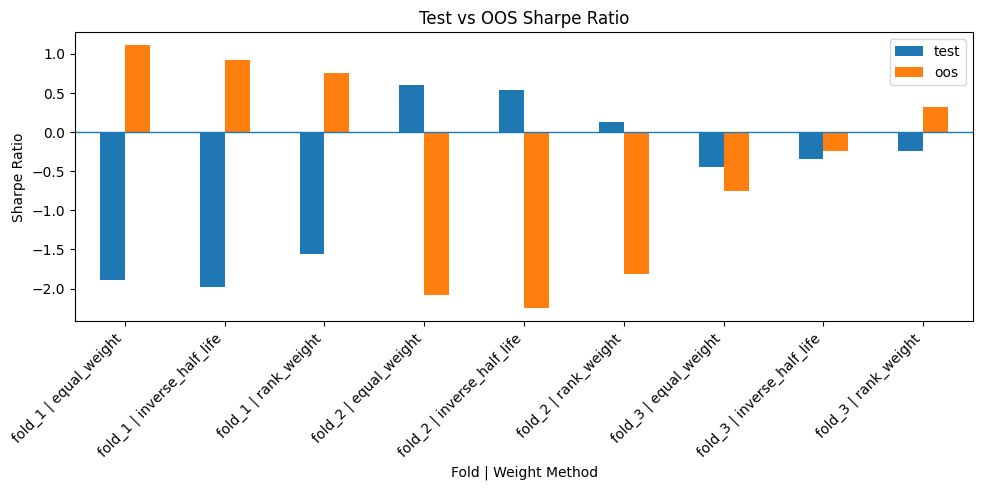

In [18]:
sharpe_plot_df = test_oos_sharpe_pivot_df.copy()

sharpe_plot_df["fold_method"] = (
    sharpe_plot_df["fold_id"].astype(str)
    + " | "
    + sharpe_plot_df["weight_method"].astype(str)
)

sharpe_plot_df = sharpe_plot_df.sort_values(["fold_id", "weight_method"])
plot_df = sharpe_plot_df.set_index("fold_method")[["test", "oos"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, linewidth=1)
plt.title("Test vs OOS Sharpe Ratio")
plt.xlabel("Fold | Weight Method")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The Sharpe ratio comparison shows that risk-adjusted performance does not persist consistently from test to OOS. Fold 1 improves from negative test Sharpe to positive OOS Sharpe, while Fold 2 deteriorates from positive test Sharpe to negative OOS Sharpe. Fold 3 remains weak or mixed across weighting methods.

This indicates that the current V2 signal is regime-sensitive and does not demonstrate stable risk-adjusted performance across validation periods.

### 7.4 Test vs OOS Annualized Return Comparison

This subsection compares annualized returns across test and OOS periods. The goal is to evaluate whether return performance observed during the test windows persists into the held-out OOS validation windows.

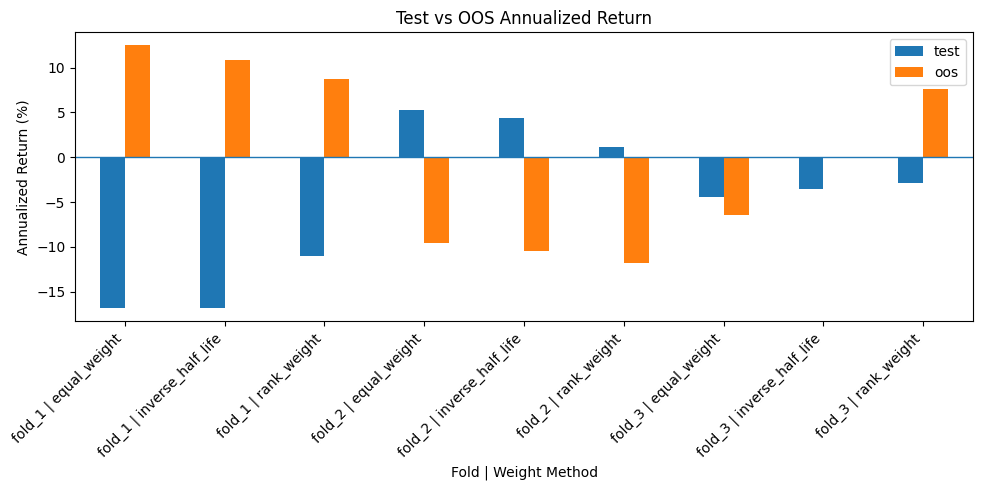

In [19]:
return_plot_df = test_oos_return_pivot_df.copy()

return_plot_df["fold_method"] = (
    return_plot_df["fold_id"].astype(str)
    + " | "
    + return_plot_df["weight_method"].astype(str)
)

return_plot_df = return_plot_df.sort_values(["fold_id", "weight_method"])
ret_plot_df = return_plot_df.set_index("fold_method")[["test", "oos"]] *100

ax = ret_plot_df.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, linewidth=1)
plt.title("Test vs OOS Annualized Return")
plt.xlabel("Fold | Weight Method")
plt.ylabel("Annualized Return (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The annualized return comparison shows that return behavior is not consistent across test and OOS periods. Fold 1 improves from negative test returns to positive OOS returns, while Fold 2 deteriorates from positive test returns to negative OOS returns. Fold 3 remains weak or mixed depending on the weighting method.

This reinforces the conclusion that the current V2 strategy configuration is regime-sensitive and does not demonstrate stable return persistence across validation periods.

### 7.5 Test vs OOS Max Drawdown Comparison

This subsection compares maximum drawdown across test and OOS periods. Drawdown is used as a downside-risk diagnostic to evaluate whether weak or unstable returns are accompanied by larger portfolio losses.

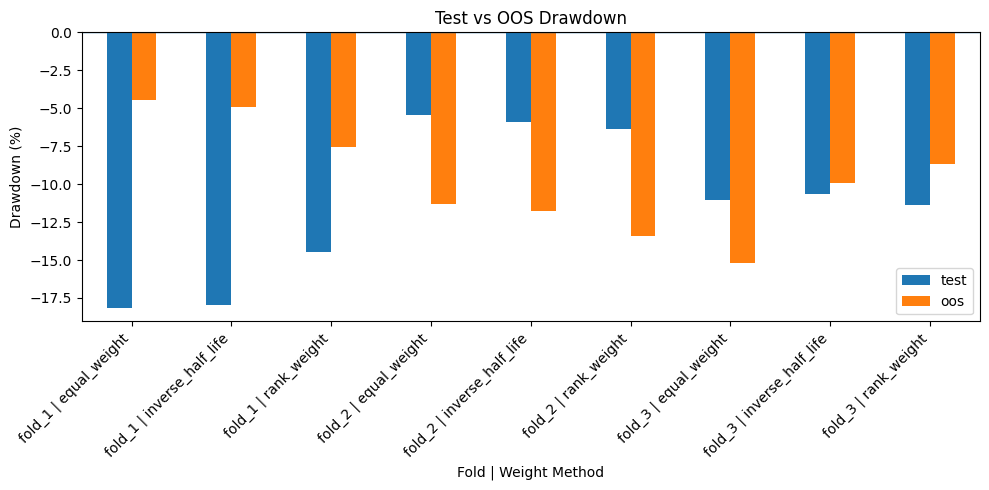

In [20]:
drawdown_plot_df = test_oos_drawdown_pivot_df.copy()

drawdown_plot_df["fold_method"] = (
    drawdown_plot_df["fold_id"].astype(str)
    + " | "
    + drawdown_plot_df["weight_method"].astype(str)
)

drawdown_plot_df = drawdown_plot_df.sort_values(["fold_id", "weight_method"])
dd_plot_df = drawdown_plot_df.set_index("fold_method")[["test", "oos"]] *100

ax = dd_plot_df.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, linewidth=1)
plt.title("Test vs OOS Drawdown")
plt.xlabel("Fold | Weight Method")
plt.ylabel("Drawdown (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The drawdown comparison shows that downside behavior also varies across folds and weighting methods. Some OOS periods have smaller drawdowns than test periods, while others experience worse drawdown behavior. This reinforces that the current strategy configuration does not demonstrate stable risk behavior across validation periods.

### 7.6 Test vs OOS Newey-West T-Stat Comparison

This subsection compares Newey-West adjusted t-statistics across test and OOS periods. The t-statistic is used as a statistical diagnostic for whether average strategy returns are meaningfully different from zero after accounting for autocorrelation and heteroskedasticity.

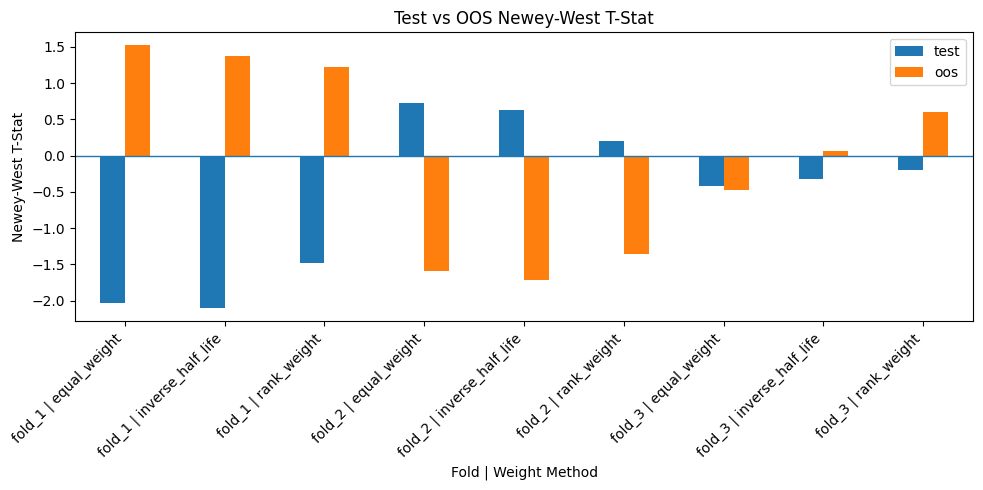

In [21]:
tstat_plot_df = test_oos_tstat_pivot_df.copy()

tstat_plot_df["fold_method"] = (
    tstat_plot_df["fold_id"].astype(str)
    + " | "
    + tstat_plot_df["weight_method"].astype(str)
)

tstat_plot_df = tstat_plot_df.sort_values(["fold_id", "weight_method"])
tstat_plot_df = tstat_plot_df.set_index("fold_method")[["test", "oos"]]

ax = tstat_plot_df.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, linewidth=1)
plt.title("Test vs OOS Newey-West T-Stat")
plt.xlabel("Fold | Weight Method")
plt.ylabel("Newey-West T-Stat")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The Newey-West t-stat comparison shows that statistical evidence is weak and inconsistent across folds and weighting methods. Most test and OOS results do not show strong statistical significance, reinforcing that the current V2 strategy configuration is not robust enough for capital deployment.

### 7.7 Test vs OOS Comparison Summary

The test vs OOS comparison shows that performance does not persist consistently across folds and weighting methods. Fold 1 improves from weak test performance to positive OOS performance, while Fold 2 shows the opposite pattern, with positive test results deteriorating into negative OOS results. Fold 3 remains weak or mixed depending on the weighting method.

Across Sharpe ratio, annualized return, max drawdown, and Newey-West t-statistics, no weighting method demonstrates stable improvement across both test and OOS periods. Equal weighting, rank weighting, and inverse-half-life weighting each perform better in some fold-period combinations, but none dominates consistently.

The key research conclusion is that the current V2 strategy configuration is not capital-ready. However, the framework itself is valuable because it identifies instability, separates test and OOS evidence, and prevents overclaiming based on isolated favorable periods.

## 8. Equity Curve Visuals

This section visualizes cumulative portfolio returns across folds and weighting methods. The equity curves are used as diagnostic visuals to inspect return path behavior, fold-level instability, and differences between test and OOS periods.

These visuals are not intended as deployment evidence on their own. They are used to understand the path dependency behind the summary metrics reported in earlier sections.

### 8.1 Load Portfolio Return Series

This subsection loads the saved portfolio return series from the Notebook 03 pickle artifact. These return series are used to construct cumulative return curves for test and OOS periods without rerunning the backtest engine.

In [22]:
v2_backtest_path = project_root/"outputs/v2_portfolio_backtest/objects/v2_portfolio_backtest_outputs.pkl"
with open(v2_backtest_path, "rb") as f:
    backtest_outputs = pickle.load(f)

type(backtest_outputs)
backtest_outputs.keys()

portfolio_returns_by_fold = backtest_outputs["portfolio_returns_by_fold"]
oos_portfolio_returns_by_fold = backtest_outputs["oos_portfolio_returns_by_fold"]

type(portfolio_returns_by_fold)
portfolio_returns_by_fold.keys()
sample_fold = list(portfolio_returns_by_fold.keys())[0]

type(portfolio_returns_by_fold[sample_fold])
portfolio_returns_by_fold[sample_fold].keys()

Index(['equal_weight', 'rank_weight', 'inverse_half_life'], dtype='str')

### 8.2 Test Equity Curve Visuals

This subsection plots cumulative portfolio returns for the test periods using the saved portfolio return series from Notebook 03. Each fold is plotted separately because fold-level portfolios are constructed from different training windows and selected-pair artifacts.

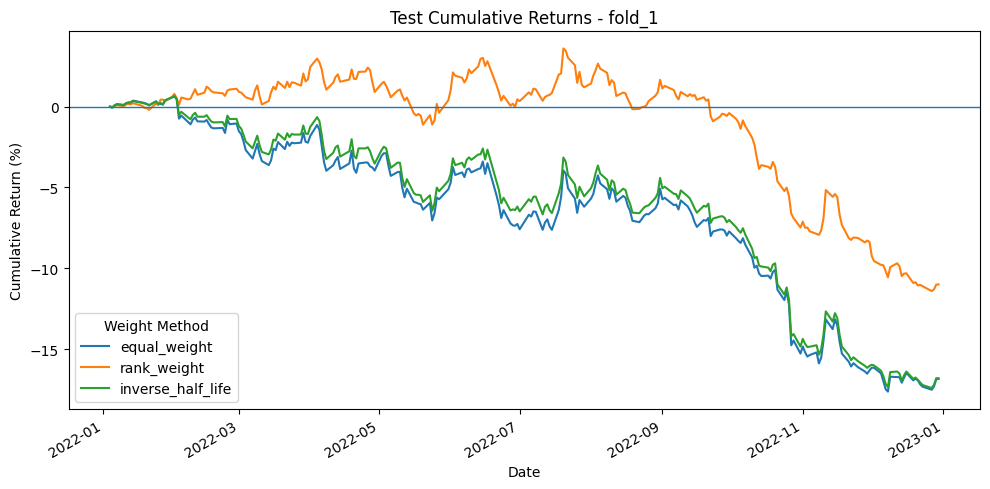

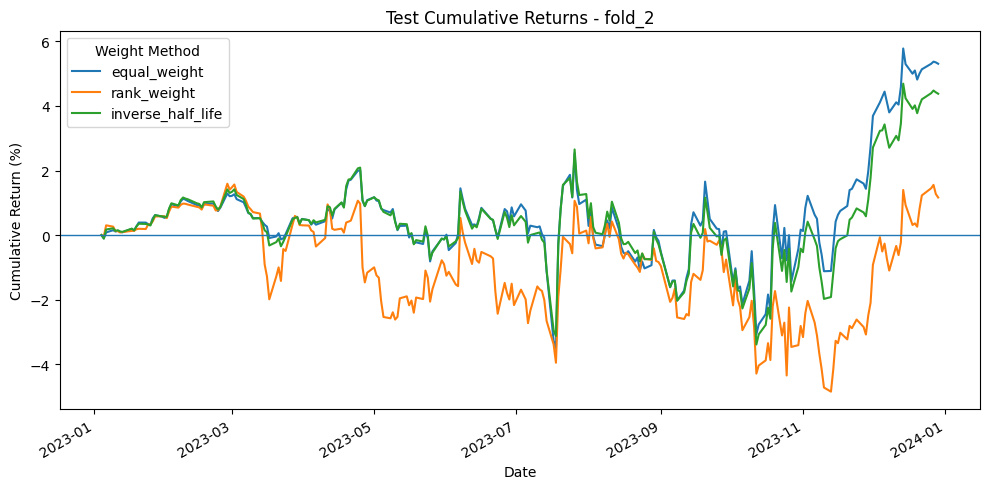

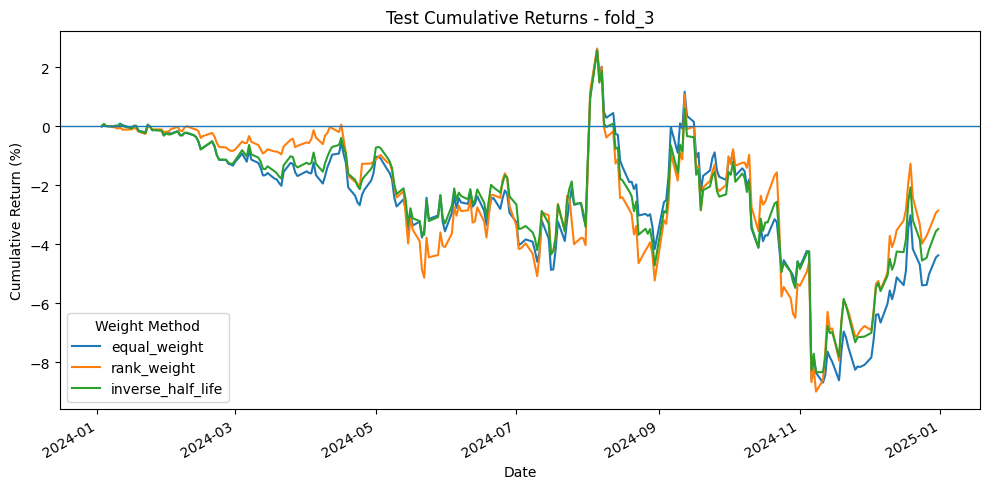

In [23]:
plot_cumulative_returns_by_fold(
    returns_by_fold=portfolio_returns_by_fold,
    title_prefix="Test"
)

### 8.3 OOS Equity Curve Visuals

This subsection plots cumulative portfolio returns for the held-out OOS periods. These curves are used to inspect path dependency and drawdown behavior in unseen validation periods.

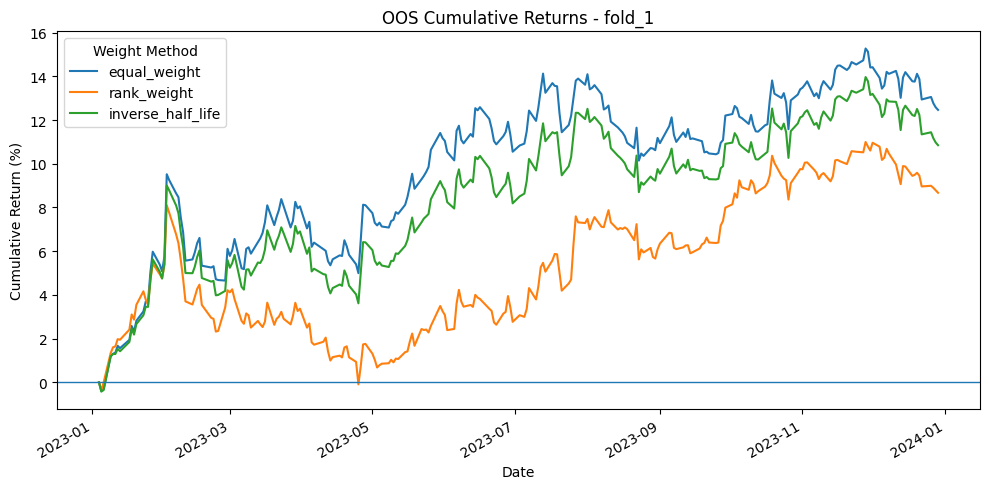

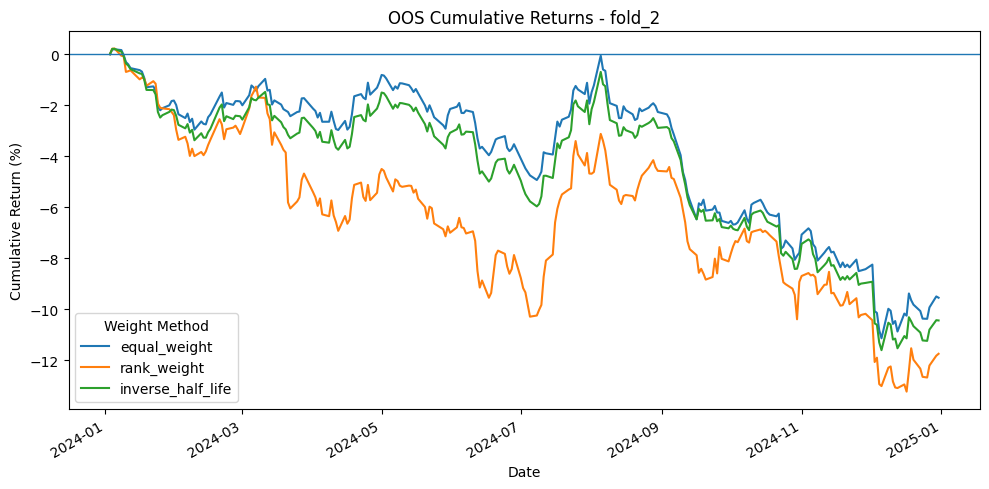

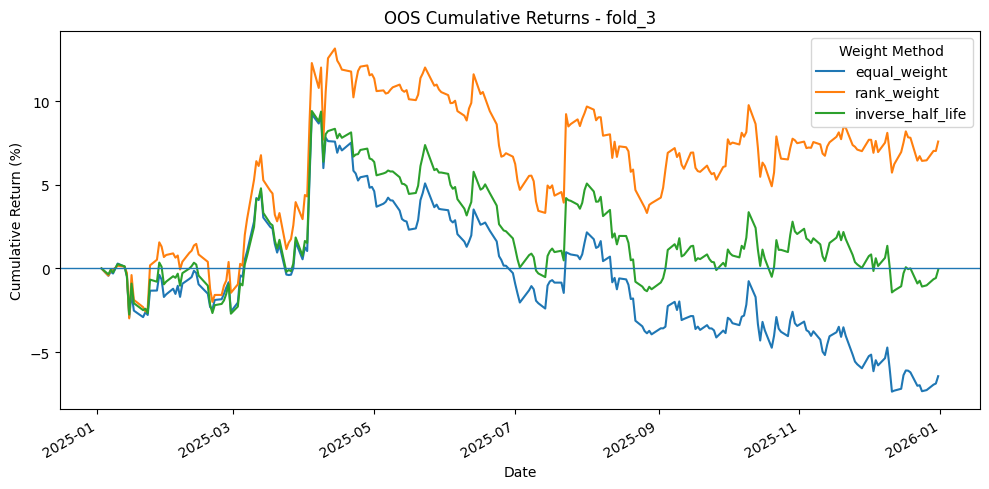

In [24]:
plot_cumulative_returns_by_fold(
    returns_by_fold=oos_portfolio_returns_by_fold,
    title_prefix="OOS"
)

## 9. Drawdown Visuals

This section visualizes drawdown behavior across folds and weighting methods. Drawdown curves are used to inspect downside path behavior, persistence of losses, and whether weak performance is associated with large portfolio declines.

### 9.1 Test Drawdown Visual

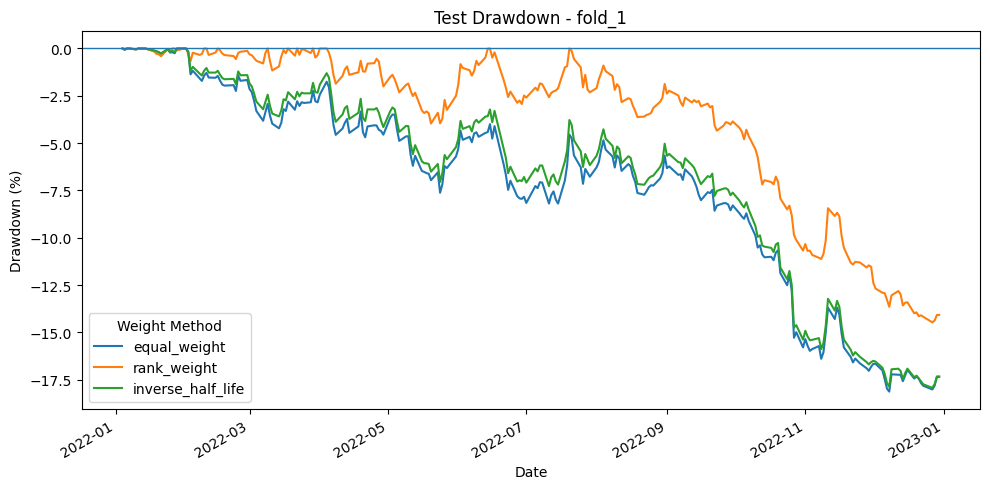

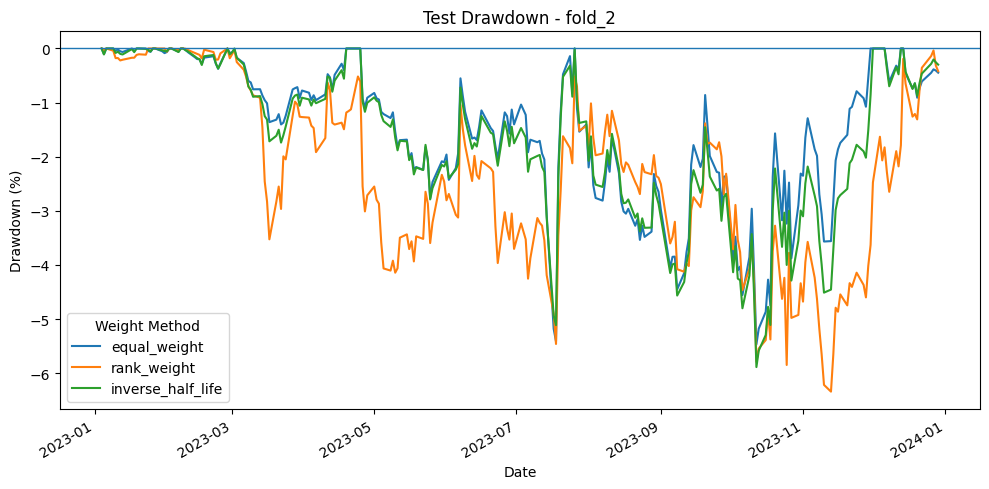

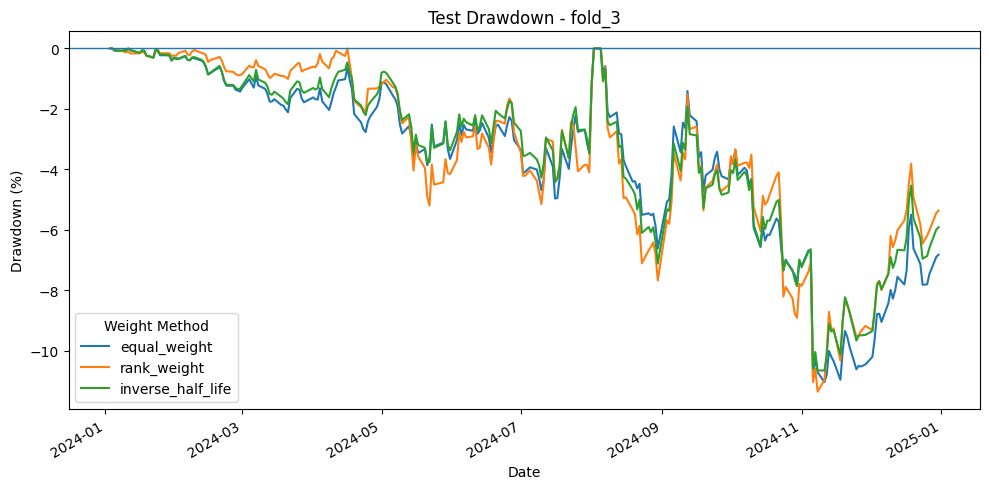

In [25]:
#For test drawdown
plot_drawdowns_by_fold(portfolio_returns_by_fold, "Test")

### 9.2 OOS Drawdown Visual

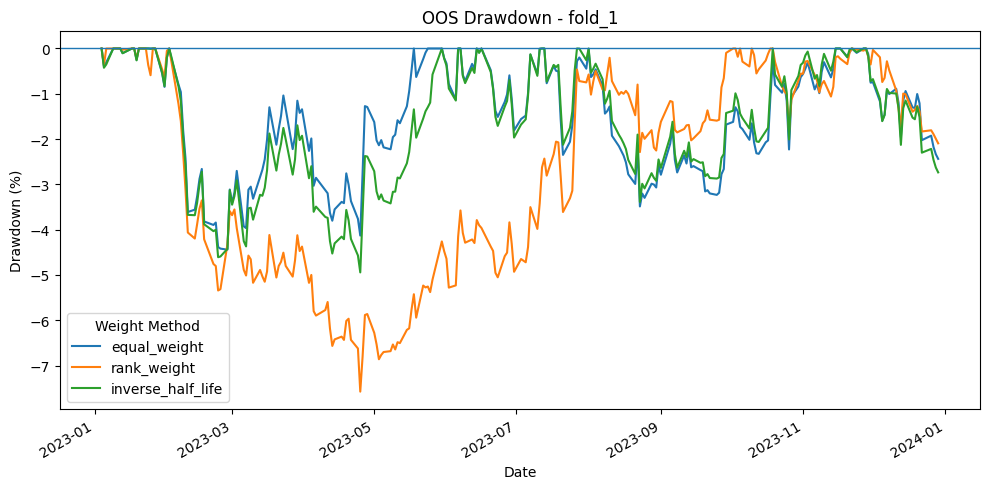

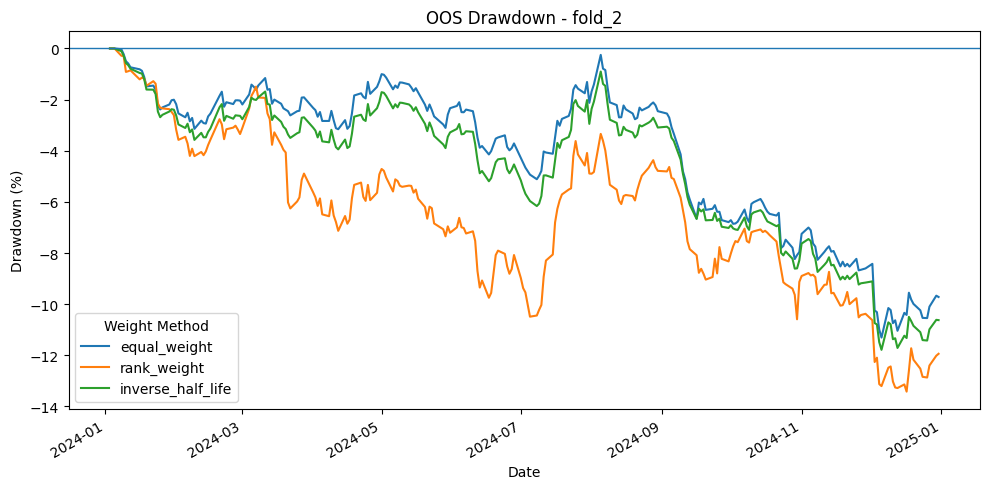

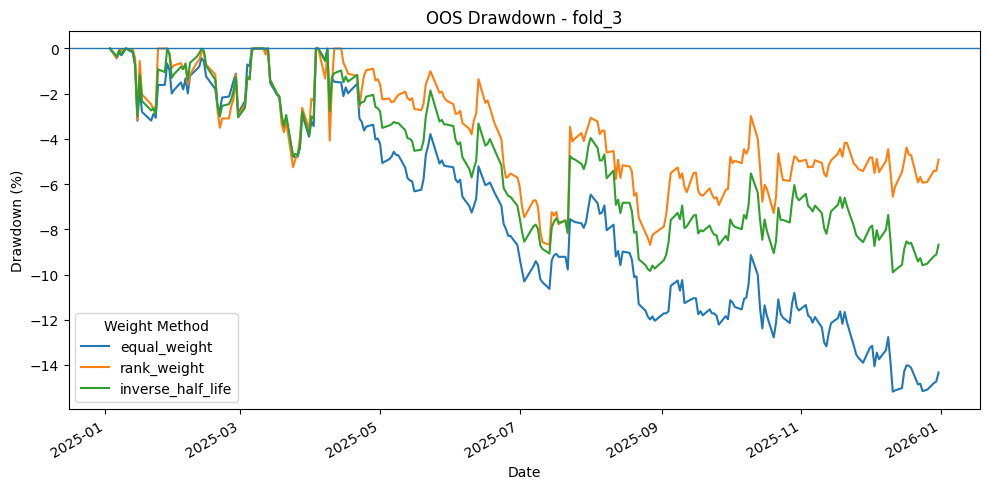

In [26]:
#For OOS drawdown
plot_drawdowns_by_fold(oos_portfolio_returns_by_fold, "OOS")

The drawdown visuals show that downside behavior varies across folds and weighting methods. Some portfolios recover relatively quickly from drawdowns, while others experience deeper or more persistent losses. No weighting method demonstrates consistently superior drawdown control across both test and OOS periods.

This supports the earlier conclusion that the current V2 strategy configuration is regime-sensitive and not yet stable enough for capital deployment.

## 10. Weighting Method Comparison

This section compares the three portfolio weighting methods across test and OOS periods.
The goal is to evaluate whether portfolio weighting improved robustness or whether signal instability remained dominant.

Datasets Used: 

test_oos_method_summary_df; and referring

 - test_oos_sharpe_pivot_df
 - test_oos_return_pivot_df
 - test_oos_drawdown_pivot_df

Questions to answer:

1. Which method had the best average Sharpe in test?
2. Which method had the best average Sharpe in OOS?
3. Which method had the best average annualized return?
4. Which method had the least severe average drawdown?
5. Did the same method win across both test and OOS?

In [27]:
required_cols = [
    "dataset",
    "weight_method",
    "annualized_return_mean",
    "sharpe_ratio_mean",
    "max_drawdown_mean",
    "hit_rate_mean",
    "newey_west_tstat_mean"
]
method_df = test_oos_method_summary_df[required_cols].copy()
method_df["annualized_return_mean"] =  method_df["annualized_return_mean"] * 100
method_df["max_drawdown_mean"] =  method_df["max_drawdown_mean"] * 100
method_df = method_df.copy().rename(columns=
    {
        "annualized_return_mean":"annualized_return_mean (%)",
        "max_drawdown_mean":"max_drawdown_mean (%)",
    }
)
numeric_cols = method_df.select_dtypes(include="number").columns
method_df[numeric_cols] = method_df[numeric_cols].round(4)
method_df = method_df.sort_values(["dataset","sharpe_ratio_mean"],ascending=[False,False]).reset_index(drop=True)

method_df

,dataset,weight_method,annualized_return_mean (%),sharpe_ratio_mean,max_drawdown_mean (%),hit_rate_mean,newey_west_tstat_mean
0,test,rank_weight,-4.2553,-0.5584,-10.7194,0.4653,-0.4918
1,test,equal_weight,-5.3237,-0.5753,-11.5425,0.4614,-0.5803
2,test,inverse_half_life,-5.3263,-0.5975,-11.4887,0.4680,-0.6002
3,oos,rank_weight,1.5581,-0.2473,-9.8945,0.4861,0.1562
4,oos,inverse_half_life,0.1406,-0.5228,-8.8787,0.4728,-0.0984
5,oos,equal_weight,-1.1574,-0.5774,-10.3096,0.4700,-0.1821


The method-level comparison suggests that rank weighting is the least weak method on average across the current V2 outputs, particularly in OOS where it has the highest mean Sharpe and positive mean annualized return. However, the evidence is not strong enough to conclude that rank weighting is a robust solution, because mean Sharpe remains negative and performance is still unstable across folds.

Overall, no weighting method demonstrates consistently strong performance across both test and OOS periods. Weighting choice alone does not resolve the instability of the current pairs trading signal.

## 11. Key Findings

The V2 pairs trading framework successfully implements an end-to-end research pipeline covering fold-specific pair selection, hedge-ratio estimation, spread construction, signal generation, pair-level backtesting, portfolio construction, test evaluation, and held-out OOS validation.

The test-period results are mixed across folds and weighting methods. Some fold/method combinations produce positive returns or Sharpe ratios, but this behavior does not persist uniformly across the validation design.

The OOS results are also mixed. No weighting method demonstrates consistently strong positive performance across all held-out OOS periods.

The weighting-method comparison suggests that `rank_weight` is the least weak method on average in the current outputs, but the evidence is not strong enough to conclude that it solves the strategy instability.

The current V2 results are reported as gross / zero-cost baseline results. They do not support immediate capital deployment.

The main value of V2 is the research infrastructure. The framework detects instability, separates test and OOS evidence, avoids overclaiming isolated favorable periods, and provides a clean foundation for future strategy improvements.

## 12. Limitations

The V2 framework provides a structured walk-forward and OOS evaluation pipeline, but several limitations remain.

First, the current universe is based on a static set of large-cap equities selected using late-2018 market-cap information. This creates a practical research universe, but it is not yet a fully dynamic or survivorship-aware universe construction process. A future version should construct fold-specific universes using only training-period information such as liquidity, price history, data availability, and tradability filters.

Second, the results in this notebook are reported as gross / zero-cost baseline results. While the project includes transaction-cost modelling assumptions at the research-design level, the current summary focuses on baseline performance before expanded cost and slippage scenario analysis. Future work should evaluate gross, base-cost, and conservative-cost scenarios.

Third, pair selection is currently based on pair-level ranking and diagnostics rather than portfolio-aware selection. This means the selected pair set may contain repeated tickers or concentrated exposures. A graph-based pair selection method, such as maximum weighted matching, could reduce repeated-asset concentration and improve portfolio construction discipline.

Fourth, the current framework does not explicitly model market regimes. The test and OOS results suggest that strategy behavior is sensitive to fold-specific market environments. Future work should evaluate volatility, stress, liquidity, or macro-regime filters before allowing capital exposure.

Fifth, the current analysis does not include benchmark-aware or factor-aware attribution. The framework evaluates portfolio returns, volatility, drawdown, hit rate, and Newey-West diagnostics, but it does not yet measure beta, factor exposure, benchmark-relative alpha, or correlation to broad equity-market risk.

Finally, the backtest uses daily data and does not model intraday execution, order-book depth, borrow constraints, tax effects, or detailed leg-level slippage. These assumptions are acceptable for a research prototype, but they would need to be expanded before any live-trading or capital-allocation decision.

These limitations do not invalidate the framework. They define the next stage of research required to move from a gross baseline statistical-arbitrage prototype toward a more realistic deployment evaluation.

## 13. V3 Roadmap

The V3 roadmap focuses on improving both strategy robustness and research infrastructure. The goal is to move from a gross baseline statistical-arbitrage research framework toward a more complete capital-deployment evaluation pipeline.

### 13.1 Fold-Level Dynamic Universe Selection

A major V3 improvement is to move universe construction inside the walk-forward process. Instead of using a static universe selected from late-2018 market-cap information, each fold should construct its own tradable universe using only training-period data.

This can be implemented through a new module such as universe_selector.py, which selects tickers based on training-window liquidity, price history, missing-data coverage, minimum observation count, and tradability filters. This reduces stale-universe bias and ensures that pair selection is performed only on assets that would have been eligible at that point in time.

### 13.2 Graph-Based Pair Selection

The current pair selection process ranks pairs individually. V3 can improve this by adding a portfolio-aware pair selection layer through a module such as pair_graph_selector.py.

In this approach, assets can be represented as nodes and candidate pairs as weighted edges. Pair quality scores can combine cointegration strength, correlation, half-life, spread stability, and liquidity. A maximum weighted matching approach can then select high-quality pairs while reducing repeated ticker exposure and concentration risk.

### 13.3 Expanded Cost Scenarios and Stress Testing

The current V2 results are presented as gross / zero-cost baseline results. V3 should add explicit gross, base-cost, and conservative-cost scenarios. This should include transaction costs, slippage assumptions, turnover-based cost drag, and stress tests under wider spread or higher-volatility assumptions.

This would allow the framework to answer whether apparent performance survives realistic implementation frictions.

### 13.4 Alpha Decay Analyzer

V3 should include an alpha decay analysis layer that compares performance degradation across train, test, and OOS periods. This would help identify whether signals decay gradually, break suddenly, or fail only under specific market regimes.

The alpha decay analyzer can track changes in return, Sharpe ratio, drawdown, hit rate, Newey-West t-statistics, pair stability, and spread behavior across validation stages.

### 13.5 CI, Logging, and Test Coverage Expansion

The research infrastructure can be strengthened by expanding test coverage across the full pipeline, including backtesting, metrics, spread modelling, walk-forward splits, and pair selection. Continuous integration can be added to automatically run tests before changes are merged.

Logging should also be expanded so that each run records configuration choices, selected universes, selected pairs, cost assumptions, fold definitions, saved artifact paths, and validation status. This would make the project more reproducible and easier to audit.

### 13.6 Capital Deployment Dashboard

The final V3 objective is to build a capital deployment dashboard that converts research outputs into a decision framework. Instead of only asking whether the strategy made money historically, the dashboard should answer:

Should this strategy be deployed?
Should it remain in paper trading?
Should exposure be reduced or paused?
Which failure mode is blocking deployment?

This dashboard can combine OOS performance, cost-adjusted returns, drawdown behavior, statistical significance, stress-test results, regime sensitivity, benchmark/factor exposure, and alpha decay diagnostics into a deploy / paper-trade / monitor / reject decision.

Overall, V3 should move the project from a validated research framework toward a more complete systematic trading evaluation platform.

## 14. Final Conclusion

The V2 pairs trading project successfully builds a reproducible walk-forward statistical-arbitrage research framework with portfolio-level test and OOS evaluation. The framework covers fold-specific pair selection, hedge-ratio estimation, spread and z-score construction, pair-level backtesting, portfolio aggregation, performance diagnostics, saved outputs, and research-summary reporting.

The current gross baseline strategy results are mixed and regime-sensitive. Test performance does not persist consistently into OOS periods, and no weighting method demonstrates sufficiently robust performance across all folds for capital deployment.

The key outcome of V2 is not a deployable trading strategy, but a disciplined research infrastructure layer. The framework separates test and OOS evidence, identifies performance instability, avoids overclaiming isolated favorable results, and creates a clean foundation for the next research iteration.

Future work should focus on fold-level dynamic universe selection, graph-based pair selection, expanded transaction-cost and slippage scenarios, alpha decay analysis, stress testing, logging and CI improvements, and a capital deployment dashboard that directly answers whether a strategy should be deployed, paper-traded, monitored, or rejected.

Overall, V2 represents a meaningful step from exploratory pairs trading analysis toward a more rigorous systematic trading research platform.